In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

In [2]:
ruta = os.path.join('..', 'Data', 'TouristAccommodationClean26012026.csv')
df = pd.read_csv(ruta)

In [3]:
df

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,False,75.0,spain,Malaga,2018-07-31,19.0,2018-07,2018,JUL
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,90.0,False,52.0,spain,Madrid,2020-01-10,31.0,2020-01,2020,JAN
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,True,142.0,spain,Sevilla,2019-07-29,34.0,2019-07,2019,JUL
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,90.0,True,306.0,spain,Barcelona,2020-01-10,27.0,2020-01,2020,JAN
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,False,39.0,spain,Girona,2019-02-19,43.0,2019-02,2019,FEB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,32392193,Espectacular habitaci�n,NaN,238089984,Sant Antoni,Eixample,Private room,1,1.0,1.0,...,NaN,True,NaN,spain,Barcelona,2019-10-16,12.0,2019-10,2019,OCT
7996,32392774,? Tu Hogar de Lujo ????? en el Centro de Sevilla,"Exclusivo, amplio y luminoso alojamiento situa...",243246681,Arenal,Casco Antiguo,Entire home/apt,6,2.0,3.0,...,100.0,False,157.0,spain,Sevilla,2021-01-31,27.0,2021-01,2021,JAN
7997,32395123,Rooms by G Bella Mar�a 3,The 2-star Bella Maria has 24-hourreception an...,159933359,Felanitx,NaN,Entire home/apt,2,1.0,1.0,...,NaN,True,NaN,spain,Mallorca,2019-04-24,9.0,2019-04,2019,APR
7998,32407332,LUMINOSO Y ENCANTADOR PISO CERCA DE TODO,PISO MUY ILUMINADO CON UNA TERRAZA ESTUPENDA C...,187631805,Proven�als del Poblenou,Sant Mart�,Private room,3,2.0,2.0,...,100.0,True,389.0,spain,Barcelona,2019-08-12,30.0,2019-08,2019,AUG


In [4]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'amenities_count', 'month', 'year',
       'month_new'],
      dtype='object')

**Analista de experiencia del cliente: Qué aspectos (precisión de detalles, higiene, check-in o
comunicación) presentan mayores diferencias entre los alojamientos mejor y peor valorados en
 la evaluación general?**

**Excluir los datos nan para que no afecte el valor real**

In [5]:
data = df[df["review_scores_rating"].notna()]

**Calcular los percentiles**

**Los percentiles 80-20 calculan diferencias de valoración general**

In [6]:
p80=data["review_scores_rating"].quantile(0.80)
p20=data["review_scores_rating"].quantile(0.20)

In [7]:
p80

np.float64(990.0)

In [8]:
p20

np.float64(870.0)

**Los percentiles 95-10 llevan un análisis con percentiles más extremos para saber diferencias entre alojamientos muy bien y muy mal evaluados**

In [9]:
p95=data["review_scores_rating"].quantile(0.95)
p10=data["review_scores_rating"].quantile(0.10)

In [10]:
p95

np.float64(1000.0)

In [11]:
p10

np.float64(800.0)

**Columnas de experiencia al cliente**

In [12]:
scores_columns = [
    "review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_cleanliness",
    "review_scores_communication"
]


**Calcular los mejores y peores puntuaciones de alojamientos**

**Percentil 80**

In [13]:
Best_accomodations = data[data["review_scores_rating"] >= p80]
Best_accomodations


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
16,101580,Big house in PARADISE,Luxury and quiet villa in Cala Canyelles (2km ...,532063,Lloret de Mar,NaN,Entire home/apt,16,4.0,4.0,...,100.0,True,73.0,spain,Girona,2018-12-22,29.0,2018-12,2018,DEC
46,326464,Charm and quiet room,<b>The space</b><br />The room is in the House...,1669001,Can Peguera,Nou Barris,Private room,2,1.0,1.0,...,100.0,False,43.0,spain,Barcelona,2021-02-09,11.0,2021-02,2021,FEB
79,461943,Lovely DoubleRoom Barcelona Center,I invite you to my amazing apartment in the mo...,2293257,la Nova Esquerra de l'Eixample,Eixample,Private room,2,1.0,1.0,...,80.0,True,10.0,spain,Barcelona,2017-06-05,13.0,2017-06,2017,JUN
87,487818,Fantastic loft-house in Soller,Former textile factory converted into a loft o...,2413652,S�ller,NaN,Entire home/apt,8,4.0,4.0,...,100.0,False,41.0,spain,Mallorca,2018-11-20,30.0,2018-11,2018,NOV
117,590991,Beautiful Cheap Double NEAR BEACH!!,We have a 3 Double Bedroom apartment 6 mins wa...,2584681,el Poblenou,Sant Mart�,Private room,2,2.0,1.0,...,80.0,False,2.0,spain,Barcelona,2018-04-12,12.0,2018-04,2018,APR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7984,32351070,Habitaci�n Doble en Madrid Centro Barrio Salam...,Habitaci�n privada en piso compartido en el ce...,9336882,Goya,Salamanca,Private room,2,1.0,1.0,...,100.0,True,334.0,spain,Madrid,2020-07-17,26.0,2020-07,2020,JUL
7985,32354363,"Double room - Gracia luxury penthouse, 2 terr...",Beautifully restored penthouse with two sunny ...,276093,la Vila de Gr�cia,Gr�cia,Private room,2,NaN,1.0,...,100.0,False,77.0,spain,Barcelona,2020-07-17,31.0,2020-07,2020,JUL
7990,32371692,1 Doble Room w Bathroom in Centric Beautiful Flat,Quieres pasar unos d�as fant�sticos en Barcelo...,9350314,el Raval,Ciutat Vella,Private room,2,1.0,1.0,...,100.0,False,38.0,spain,Barcelona,2019-05-14,18.0,2019-05,2019,MAY
7994,32391703,Traumfinca Mallorca in Santanyi f�r bis 10Pers...,"Die Finca besticht durch ihre einzigartige, ru...",85486707,Santany�,NaN,Private room,2,1.0,1.0,...,100.0,False,85.0,spain,Mallorca,2020-01-29,24.0,2020-01,2020,JAN


In [14]:
Best_accomodations = data[
    (data["review_scores_rating"] >= p80) &
    (data["number_of_reviews"] >= 10)
]
Best_accomodations

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
16,101580,Big house in PARADISE,Luxury and quiet villa in Cala Canyelles (2km ...,532063,Lloret de Mar,NaN,Entire home/apt,16,4.0,4.0,...,100.0,True,73.0,spain,Girona,2018-12-22,29.0,2018-12,2018,DEC
46,326464,Charm and quiet room,<b>The space</b><br />The room is in the House...,1669001,Can Peguera,Nou Barris,Private room,2,1.0,1.0,...,100.0,False,43.0,spain,Barcelona,2021-02-09,11.0,2021-02,2021,FEB
87,487818,Fantastic loft-house in Soller,Former textile factory converted into a loft o...,2413652,S�ller,NaN,Entire home/apt,8,4.0,4.0,...,100.0,False,41.0,spain,Mallorca,2018-11-20,30.0,2018-11,2018,NOV
120,602284,2 Rooms in amazing entire penthouse up to 6 gu...,"Welcoming, bright and cosy holiday penthouse e...",2937042,la Vila de Gr�cia,Gr�cia,Entire home/apt,6,1.0,2.0,...,100.0,True,25.0,spain,Barcelona,2018-09-11,32.0,2018-09,2018,SEP
173,751527,Gran apartamento Plaza de Espa�a,Apartamento con 7 piezas: 3 dormitorios y una ...,3951702,Universidad,Centro,Entire home/apt,9,3.0,4.0,...,100.0,False,93.0,spain,Madrid,2017-03-06,19.0,2017-03,2017,MAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7917,32035417,Central apartment with private barbecue.,Charming Apartment located in the center of Ma...,159608815,Centro,NaN,Entire home/apt,4,1.0,2.0,...,100.0,True,18.0,spain,Malaga,2020-03-26,39.0,2020-03,2020,MAR
7976,32313873,Double Room w/pvt. Bathroom & Terrace in Poble...,"With its privileged location, just five minute...",3006671,el Poble Sec,Sants-Montju�c,Private room,2,1.0,1.0,...,100.0,False,183.0,spain,Barcelona,2020-09-12,26.0,2020-09,2020,SEP
7984,32351070,Habitaci�n Doble en Madrid Centro Barrio Salam...,Habitaci�n privada en piso compartido en el ce...,9336882,Goya,Salamanca,Private room,2,1.0,1.0,...,100.0,True,334.0,spain,Madrid,2020-07-17,26.0,2020-07,2020,JUL
7985,32354363,"Double room - Gracia luxury penthouse, 2 terr...",Beautifully restored penthouse with two sunny ...,276093,la Vila de Gr�cia,Gr�cia,Private room,2,NaN,1.0,...,100.0,False,77.0,spain,Barcelona,2020-07-17,31.0,2020-07,2020,JUL


In [15]:
Best_accomodations = Best_accomodations.sort_values(
    ["review_scores_rating", "number_of_reviews"],
    ascending=[False, False]
)

Best_accomodations[["name", "review_scores_rating", "number_of_reviews", "price","review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_cleanliness",
    "review_scores_communication"]].head(10)


,name,review_scores_rating,number_of_reviews,price,review_scores_accuracy,review_scores_checkin,review_scores_cleanliness,review_scores_communication
2217,Vivienda San Mart�n II,1000.0,194,530.0,100.0,100.0,100.0,100.0
2218,Vivienda San Mart�n II,1000.0,178,650.0,100.0,100.0,100.0,100.0
1783,Casa sevillana en barrio historico,1000.0,154,200.0,100.0,100.0,100.0,100.0
5759,"Stylish Apt PZA MAYOR/La Latina 2BD* 2BT*, 6p max",1000.0,134,780.0,100.0,100.0,100.0,100.0
6072,Romantic and Rustic Penthouse with a Sun Kisse...,1000.0,128,680.0,90.0,100.0,100.0,100.0
3365,BCN Luxury,1000.0,104,1950.0,100.0,100.0,100.0,100.0
5587,Private room in detached house,1000.0,104,400.0,100.0,100.0,100.0,100.0
309,"MAGIC PLACE IN BARCELONA, WITH POOL",1000.0,92,1300.0,100.0,100.0,100.0,100.0
3717,"Cubic House Garden, Cala Morlanda.",1000.0,85,900.0,100.0,100.0,100.0,100.0
5404,Typical majorcan house in Llucmajor,1000.0,85,1200.0,100.0,100.0,100.0,100.0


*Percentil 95*

In [16]:
Best_accomodations2 = data[data["review_scores_rating"] >= p95]
Best_accomodations2

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
79,461943,Lovely DoubleRoom Barcelona Center,I invite you to my amazing apartment in the mo...,2293257,la Nova Esquerra de l'Eixample,Eixample,Private room,2,1.0,1.0,...,80.0,True,10.0,spain,Barcelona,2017-06-05,13.0,2017-06,2017,JUN
117,590991,Beautiful Cheap Double NEAR BEACH!!,We have a 3 Double Bedroom apartment 6 mins wa...,2584681,el Poblenou,Sant Mart�,Private room,2,2.0,1.0,...,80.0,False,2.0,spain,Barcelona,2018-04-12,12.0,2018-04,2018,APR
134,640268,**Nice and relax Couple Room**,Hello ! Are you looking for a nice place for y...,3196093,la Nova Esquerra de l'Eixample,Eixample,Private room,2,1.0,1.0,...,100.0,False,6.0,spain,Barcelona,2018-07-10,4.0,2018-07,2018,JUL
157,717300,Mar Blau - 0114,Welcome to Marblau! This apartment in the cent...,3625030,Alc�dia,NaN,Entire home/apt,4,2.0,2.0,...,100.0,True,11.0,spain,Mallorca,2017-03-15,6.0,2017-03,2017,MAR
173,751527,Gran apartamento Plaza de Espa�a,Apartamento con 7 piezas: 3 dormitorios y una ...,3951702,Universidad,Centro,Entire home/apt,9,3.0,4.0,...,100.0,False,93.0,spain,Madrid,2017-03-06,19.0,2017-03,2017,MAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7983,32337607,S'Hort de Marina,S'Hort de Marina is located in the surrounding...,242783523,Campos,NaN,Entire home/apt,8,5.0,4.0,...,100.0,True,67.0,spain,Mallorca,2019-05-27,38.0,2019-05,2019,MAY
7985,32354363,"Double room - Gracia luxury penthouse, 2 terr...",Beautifully restored penthouse with two sunny ...,276093,la Vila de Gr�cia,Gr�cia,Private room,2,NaN,1.0,...,100.0,False,77.0,spain,Barcelona,2020-07-17,31.0,2020-07,2020,JUL
7990,32371692,1 Doble Room w Bathroom in Centric Beautiful Flat,Quieres pasar unos d�as fant�sticos en Barcelo...,9350314,el Raval,Ciutat Vella,Private room,2,1.0,1.0,...,100.0,False,38.0,spain,Barcelona,2019-05-14,18.0,2019-05,2019,MAY
7994,32391703,Traumfinca Mallorca in Santanyi f�r bis 10Pers...,"Die Finca besticht durch ihre einzigartige, ru...",85486707,Santany�,NaN,Private room,2,1.0,1.0,...,100.0,False,85.0,spain,Mallorca,2020-01-29,24.0,2020-01,2020,JAN


In [17]:
Best_accomodations2 = data[
    (data["review_scores_rating"] >= p95) &
    (data["number_of_reviews"] >= 10)
]
Best_accomodations2

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
173,751527,Gran apartamento Plaza de Espa�a,Apartamento con 7 piezas: 3 dormitorios y una ...,3951702,Universidad,Centro,Entire home/apt,9,3.0,4.0,...,100.0,False,93.0,spain,Madrid,2017-03-06,19.0,2017-03,2017,MAR
309,1073748,"MAGIC PLACE IN BARCELONA, WITH POOL",<b>The space</b><br />MAGIC PLACE IN BARCELONA...,5159312,"Vallvidrera, el Tibidabo i les Planes",Sarri�-Sant Gervasi,Entire home/apt,4,1.0,1.0,...,100.0,True,101.0,spain,Barcelona,2020-11-06,40.0,2020-11,2020,NOV
530,1959017,JESUS Pollensa,"In the Old Town Pollensa, next to Calvario ste...",5460753,Pollen�a,NaN,Entire home/apt,6,2.0,3.0,...,100.0,False,16.0,spain,Mallorca,2019-05-27,23.0,2019-05,2019,MAY
655,2669792,"Acogedor, centrico y cerca del mar","Mi apartamento es c�ntrico, situado en una cas...",3601423,Palma de Mallorca,NaN,Private room,1,1.0,1.0,...,100.0,False,56.0,spain,Mallorca,2020-11-08,7.0,2020-11,2020,NOV
876,3764223,Habitaci�n chalet Limonar M�laga 2,"Habitaci�n de dos camas, ba�o privado en chale...",19279251,Este,NaN,Private room,2,1.0,1.0,...,100.0,False,191.0,spain,Malaga,2018-04-22,11.0,2018-04,2018,APR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7768,31309107,Superb Central 2 Bedroom Apt near Pr�ncipe P�o,Renovated 2 bedroom apt with interior balcony ...,234340731,Casa de Campo,Moncloa - Aravaca,Entire home/apt,4,1.0,2.0,...,100.0,True,177.0,spain,Madrid,2019-12-10,30.0,2019-12,2019,DEC
7795,31452541,Penthouse with wonderfull terrace in the center.,Modern penthouse with private terrace where yo...,159455813,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,True,596.0,spain,Sevilla,2019-06-29,40.0,2019-06,2019,JUN
7812,31548396,Modern apartment on the beach.,"New apartment with sea views, located 5 meters...",38921329,Sant Lloren� des Cardassar,NaN,Entire home/apt,4,1.0,2.0,...,100.0,True,63.0,spain,Mallorca,2021-01-16,29.0,2021-01,2021,JAN
7985,32354363,"Double room - Gracia luxury penthouse, 2 terr...",Beautifully restored penthouse with two sunny ...,276093,la Vila de Gr�cia,Gr�cia,Private room,2,NaN,1.0,...,100.0,False,77.0,spain,Barcelona,2020-07-17,31.0,2020-07,2020,JUL


**Calcular las peores puntuaciones de los alojamientos**

**Percentil 20**

In [18]:
worst_accomodations = data[
    (data["review_scores_rating"] <= p20) &
    (data["number_of_reviews"] >= 10)
]
worst_accomodations

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
10,73692,Rustic apartment : Rambla Catalunya (HUTB-005863),Located in the centre of Barcelona (near Plaza...,297545,la Dreta de l'Eixample,Eixample,Entire home/apt,5,1.0,2.0,...,90.0,True,46.0,spain,Barcelona,2017-10-07,14.0,2017-10,2017,OCT
22,144471,BEST ZONEPL.CATALU�A ROOM X 2BATHROOM +WIFI,HELLO PEOPLE :=) are you on vacation? or busi...,700165,Sant Antoni,Eixample,Private room,2,1.0,1.0,...,80.0,False,42.0,spain,Barcelona,2017-09-12,7.0,2017-09,2017,SEP
29,176827,Se alquilan habitaciones en Madrid,Es un piso totalmente reformado. Todas las hab...,845399,Universidad,Centro,Private room,7,5.0,1.0,...,90.0,True,248.0,spain,Madrid,2017-04-08,17.0,2017-04,2017,APR
31,183346,ROOM IN CENTRAL REFURBISH FLAT,I RENT a room in my fully big (125 m2) just re...,877571,Justicia,Centro,Private room,2,2.0,1.0,...,80.0,False,24.0,spain,Madrid,2018-01-17,21.0,2018-01,2018,JAN
38,222753,House near City Arts+Wi-fi,House with interior garden just few minutes fr...,709516,EN CORTS,QUATRE CARRERES,Private room,3,1.0,2.0,...,90.0,False,156.0,spain,Valencia,2020-11-10,24.0,2020-11,2020,NOV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7915,32032467,Habitaci�n,NaN,240158984,el Camp de l'Arpa del Clot,Sant Mart�,Private room,2,1.0,1.0,...,70.0,False,19.0,spain,Barcelona,2019-07-10,9.0,2019-07,2019,JUL
7928,32096721,Habitaci�n carabanchel,"Habitaci�n c�moda adaptada para una persona , ...",186088359,Buenavista,Carabanchel,Private room,1,1.0,1.0,...,80.0,True,86.0,spain,Madrid,2020-06-13,7.0,2020-06,2020,JUN
7929,32104558,"Cosy 1Bed Apt in Madrid, 5mins to metro","Welcome to my lovely, modern apartment - the p...",236975051,San Diego,Puente de Vallecas,Entire home/apt,4,1.0,1.0,...,80.0,True,78.0,spain,Madrid,2020-04-17,17.0,2020-04,2020,APR
7970,32284453,EXPERIENCE IN BIG CARAVAN MALLORCA,ENJOY IN NATURAL EMVIROMENENT AT 2 KM PALMA BE...,4854196,Palma de Mallorca,NaN,Entire home/apt,4,2.0,2.0,...,90.0,True,71.0,spain,Mallorca,2020-11-08,16.0,2020-11,2020,NOV


In [19]:
worst_accomodations = worst_accomodations.sort_values(
    ["review_scores_rating", "number_of_reviews"],
    ascending=[True, False]
)

worst_accomodations[["name", "review_scores_rating", "number_of_reviews", "price","review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_cleanliness",
    "review_scores_communication"]].head(10)


,name,review_scores_rating,number_of_reviews,price,review_scores_accuracy,review_scores_checkin,review_scores_cleanliness,review_scores_communication
7258,Apartamento Centro De Madrid Atocha,640.0,10,590.0,80.0,90.0,70.0,90.0
3556,Superb studio 2 p front of the sea with swim ...,660.0,22,340.0,70.0,90.0,70.0,90.0
5020,Bright apartment in the heart of Barcelona,670.0,10,990.0,50.0,80.0,50.0,70.0
7915,Habitaci�n,670.0,10,350.0,70.0,90.0,80.0,70.0
3682,GREAT CENTRAL ROOM IN BARRIO G�TICO...,680.0,25,330.0,70.0,80.0,70.0,70.0
1489,Harmonious Madrazo,690.0,21,1100.0,80.0,90.0,70.0,80.0
4629,Charming Studio 2/3 pers with pool !!!,700.0,10,450.0,70.0,90.0,80.0,80.0
354,Rocafort 1 Apartment,710.0,27,850.0,70.0,90.0,70.0,90.0
2133,City Center Studio Gracia 2,710.0,24,600.0,80.0,90.0,80.0,70.0
2802,VERY CHEAP APARTMENT IN THE CENTER,720.0,33,900.0,80.0,90.0,70.0,90.0


*Percentil 10*

In [20]:
worst_accomodations2 = data[
    (data["review_scores_rating"] <= p10) &
    (data["number_of_reviews"] >= 10)
]
worst_accomodations

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,amenities_count,month,year,month_new
7258,28560520,Apartamento Centro De Madrid Atocha,"El alojamiento cuenta con dos camas King, es u...",206942792,Embajadores,Centro,Entire home/apt,4,1.0,1.0,...,80.0,True,74.0,spain,Madrid,2019-11-09,13.0,2019-11,2019,NOV
3556,16940499,Superb studio 2 p front of the sea with swim ...,In a superb and rare setting on ROSAS and its ...,95391346,Roses,NaN,Entire home/apt,2,1.0,0.0,...,70.0,True,116.0,spain,Girona,2018-09-28,24.0,2018-09,2018,SEP
5020,20659449,Bright apartment in the heart of Barcelona,Big apartment with a terrace in the back situa...,136903035,la Dreta de l'Eixample,Eixample,Private room,6,1.0,2.0,...,60.0,True,47.0,spain,Barcelona,2019-06-07,7.0,2019-06,2019,JUN
7915,32032467,Habitaci�n,NaN,240158984,el Camp de l'Arpa del Clot,Sant Mart�,Private room,2,1.0,1.0,...,70.0,False,19.0,spain,Barcelona,2019-07-10,9.0,2019-07,2019,JUL
3682,17299186,GREAT CENTRAL ROOM IN BARRIO G�TICO...,"Great central, and quiet room in the heart of ...",116039097,el Barri G�tic,Ciutat Vella,Private room,2,1.0,1.0,...,70.0,False,359.0,spain,Barcelona,2017-10-07,13.0,2017-10,2017,OCT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5004,20604596,Preciosa habitaci�n compartida en Centro madrid��,"Contamos con estancias amplias, luminosas y ac...",139789014,Universidad,Centro,Shared room,1,2.0,1.0,...,90.0,True,97.0,spain,Madrid,2018-08-14,9.0,2018-08,2018,AUG
6241,24249549,Elegant 4 bedrooms flat in the very City Center!!,In the very Plaza de la Cebada Sq you will fin...,8244614,Palacio,Centro,Entire home/apt,6,3.0,4.0,...,90.0,False,114.0,spain,Madrid,2019-02-06,17.0,2019-02,2019,FEB
7557,30343702,Muy bien comunicado con el centro de Madrid,"Apartamento de 60m2, luminoso y acogedor. Situ...",43178675,C�rmenes,Latina,Entire home/apt,4,2.0,1.0,...,80.0,False,43.0,spain,Madrid,2021-02-09,19.0,2021-02,2021,FEB
1886,9853291,Large Apartment Centelles,Bright apartment located in La dreta de l'Eixa...,1391607,el Camp de l'Arpa del Clot,Sant Mart�,Entire home/apt,6,1.0,3.0,...,90.0,False,25.0,spain,Barcelona,2019-04-10,20.0,2019-04,2019,APR


In [21]:
worst_accomodations2 = worst_accomodations2.sort_values(
    ["review_scores_rating", "number_of_reviews"],
    ascending=[True, False]
)

worst_accomodations2[["name", "review_scores_rating", "number_of_reviews", "price","review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_cleanliness",
    "review_scores_communication"]].head(10)

,name,review_scores_rating,number_of_reviews,price,review_scores_accuracy,review_scores_checkin,review_scores_cleanliness,review_scores_communication
7258,Apartamento Centro De Madrid Atocha,640.0,10,590.0,80.0,90.0,70.0,90.0
3556,Superb studio 2 p front of the sea with swim ...,660.0,22,340.0,70.0,90.0,70.0,90.0
5020,Bright apartment in the heart of Barcelona,670.0,10,990.0,50.0,80.0,50.0,70.0
7915,Habitaci�n,670.0,10,350.0,70.0,90.0,80.0,70.0
3682,GREAT CENTRAL ROOM IN BARRIO G�TICO...,680.0,25,330.0,70.0,80.0,70.0,70.0
1489,Harmonious Madrazo,690.0,21,1100.0,80.0,90.0,70.0,80.0
4629,Charming Studio 2/3 pers with pool !!!,700.0,10,450.0,70.0,90.0,80.0,80.0
354,Rocafort 1 Apartment,710.0,27,850.0,70.0,90.0,70.0,90.0
2133,City Center Studio Gracia 2,710.0,24,600.0,80.0,90.0,80.0,70.0
2802,VERY CHEAP APARTMENT IN THE CENTER,720.0,33,900.0,80.0,90.0,70.0,90.0


**Calcular la media de las puntuaciones**

*percentil 80*

In [22]:
media_best_accomodations = Best_accomodations[scores_columns].mean()
media_best_accomodations

review_scores_accuracy         99.886364
review_scores_checkin          99.801136
review_scores_cleanliness      99.715909
review_scores_communication    99.857955
dtype: float64

*Percentil 95*

In [23]:
media_best_accomodations2=Best_accomodations[scores_columns].mean()
media_best_accomodations2

review_scores_accuracy         99.886364
review_scores_checkin          99.801136
review_scores_cleanliness      99.715909
review_scores_communication    99.857955
dtype: float64

*Percentil 20*

In [24]:
media_worst_accomodations = worst_accomodations[scores_columns].mean()
media_worst_accomodations

review_scores_accuracy         88.083183
review_scores_checkin          91.555154
review_scores_cleanliness      85.515371
review_scores_communication    91.229656
dtype: float64

*Percentil 10*

In [25]:
media_worst_accomodations2 = worst_accomodations2[scores_columns].mean()
media_worst_accomodations2

review_scores_accuracy         82.095238
review_scores_checkin          88.571429
review_scores_cleanliness      79.619048
review_scores_communication    86.857143
dtype: float64

**Calcular la diferencia de las puntuaciones**

**Diferencia entre Percentil 80/20**

*Se muestra la importancia de la limpieza y la precisión, se representa el comportamiento general*

In [26]:
difference = (media_best_accomodations - media_worst_accomodations).sort_values(ascending=False) 
print(difference)

review_scores_cleanliness      14.200538
review_scores_accuracy         11.803181
review_scores_communication     8.628298
review_scores_checkin           8.245983
dtype: float64


**Diferencia entre percentil 95/10**

*Se muestran casos extremos que confirman los resultados*

In [27]:
difference2 = (media_best_accomodations2 - media_worst_accomodations2).sort_values(ascending=False) 
print(difference2)

review_scores_cleanliness      20.096861
review_scores_accuracy         17.791126
review_scores_communication    13.000812
review_scores_checkin          11.229708
dtype: float64


**Visualizaciones**

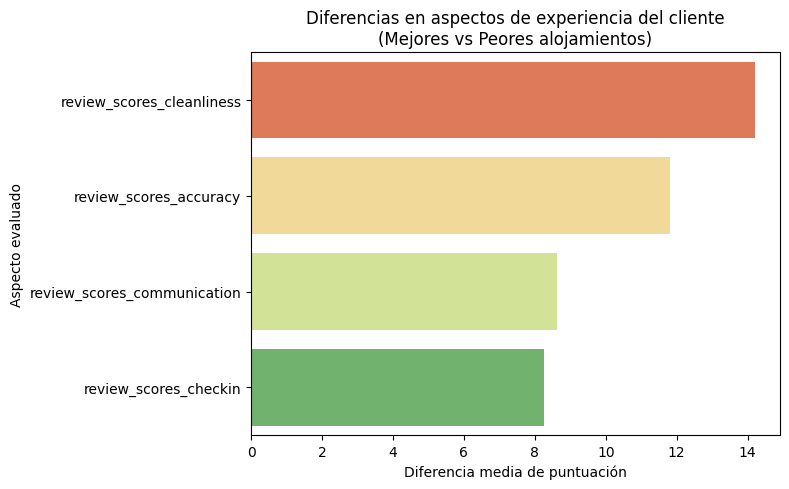

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=difference.values,
    y=difference.index,
    hue=difference.index,
    palette="RdYlGn",
    legend=False
)

plt.title("Diferencias en aspectos de experiencia del cliente\n(Mejores vs Peores alojamientos)")
plt.xlabel("Diferencia media de puntuación")
plt.ylabel("Aspecto evaluado")
plt.tight_layout()
plt.show()


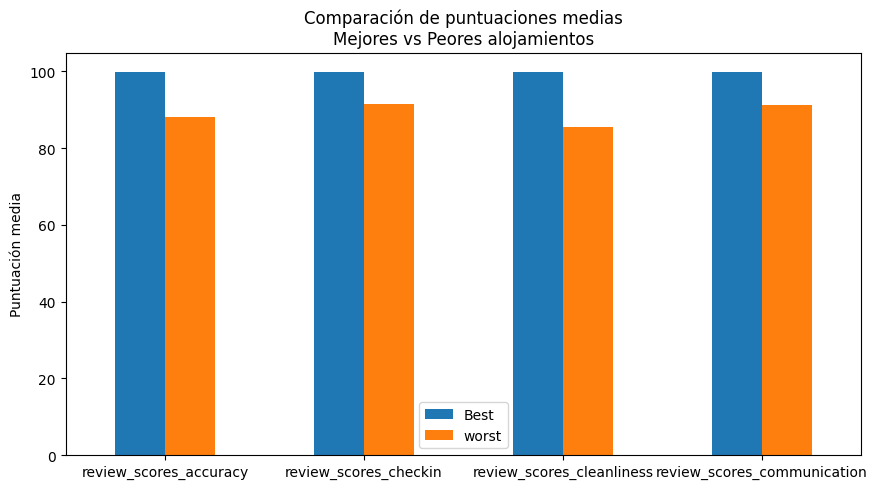

In [32]:
comparison_df = pd.DataFrame({
    "Best": media_best_accomodations,
    "worst": media_worst_accomodations
})

comparison_df.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Comparación de puntuaciones medias\nMejores vs Peores alojamientos")
plt.ylabel("Puntuación media")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()


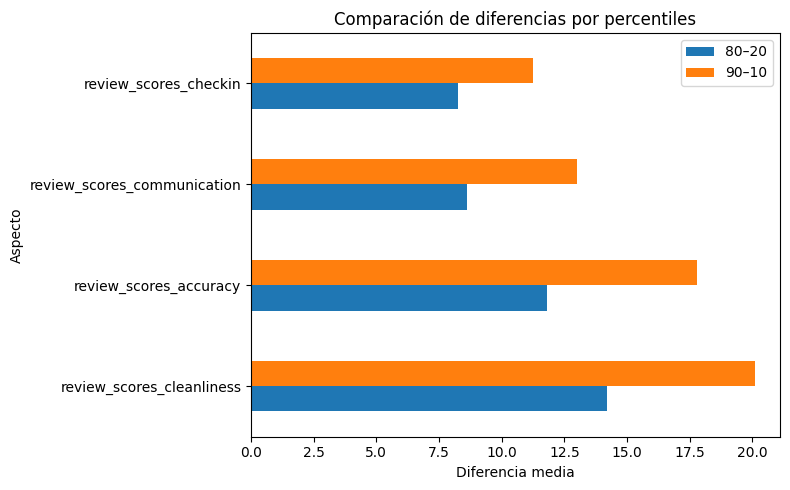

In [30]:
comparison_percentiles = pd.DataFrame({
    "80–20": difference,
    "90–10": difference2
})

comparison_percentiles.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Comparación de diferencias por percentiles")
plt.xlabel("Diferencia media")
plt.ylabel("Aspecto")
plt.tight_layout()
plt.show()


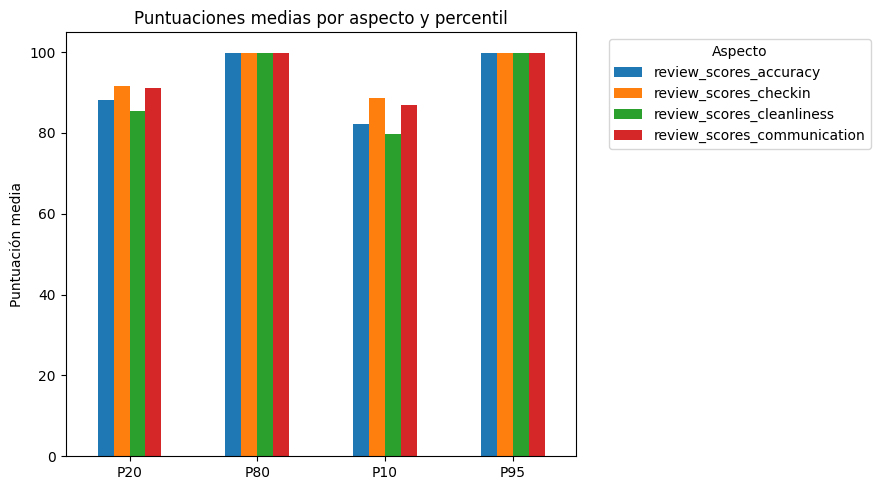

In [31]:
percentiles_df = pd.DataFrame({
    "P20": media_worst_accomodations,
    "P80": media_best_accomodations,
     "P10": media_worst_accomodations2,
    "P95": media_best_accomodations2
})

# Transponer para graficar
percentiles_df = percentiles_df.T

# Barplot
percentiles_df.plot(kind="bar", figsize=(9,5))
plt.title("Puntuaciones medias por aspecto y percentil")
plt.ylabel("Puntuación media")
plt.xticks(rotation=0)
plt.legend(title="Aspecto", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
